<a href="https://colab.research.google.com/github/Adeela-saleem/MachineLearning_Algorithms/blob/main/GradientDescent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression ki working aur Gradient Descent ka concept samjhane ke liye banaya gaya hai.

In [1]:
from sklearn.datasets import make_regression

In [2]:
import numpy as np

In [3]:
X,y=make_regression(n_samples=4,n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)


X,y = make_regression(n_samples=4, n_features=1, n_informative=1, n_targets=1,noise=80,random_state=13)


In [4]:
import matplotlib.pyplot as plt

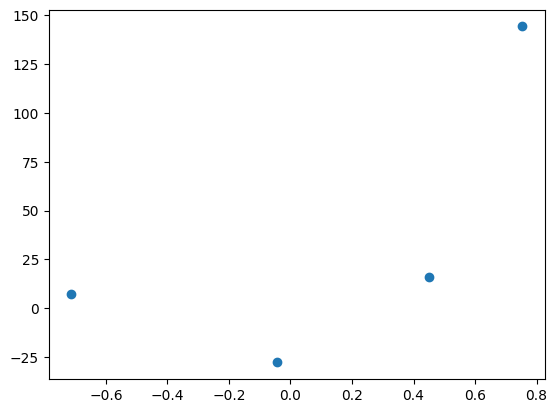

In [5]:
plt.scatter(X,y)

In [ ]:
#by apply OLS (ORDINARY LEAST SQUARE METHOD which is used by scikit learn)

In [6]:
from sklearn.linear_model import LinearRegression

In [7]:
reg = LinearRegression()
reg.fit(X,y)

LinearRegression()

In [8]:
reg.coef_

array([78.35063668])

In [9]:
reg.intercept_

np.float64(26.15963284313262)

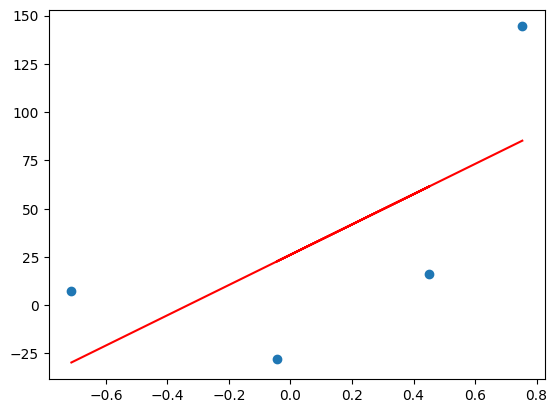

In [10]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red')

let's apply GD  by assuming m constant=[78.3]
and starting value of intercept b=0

In [ ]:
#calculate y predict
y_pred=(reg.coef_*X)+reg.intercept_

In [14]:
y_pred = ((78.35 * X) + 0).reshape(4) #in 1d while initially (4,1)


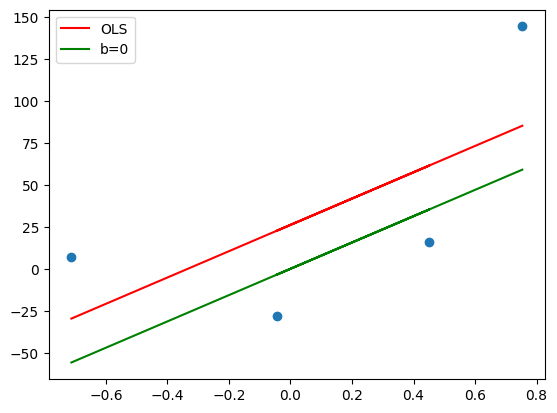

In [15]:
plt.scatter(X,y)
plt.plot(X,reg.predict(X),color='red',label='OLS')
plt.plot(X,y_pred,color='green',label='b=0')
plt.legend()
plt.show()

m * X.ravel() ka matlab array X ko 1D (one-dimensional) array mein convert karke use scalar m se multiply karna hai.

In [16]:
m=78.35
b=0
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(-209.27763408209216)

In [17]:
lr=0.1

In [19]:
b=b-(lr*loss_slope)
b

np.float64(41.85552681641843)

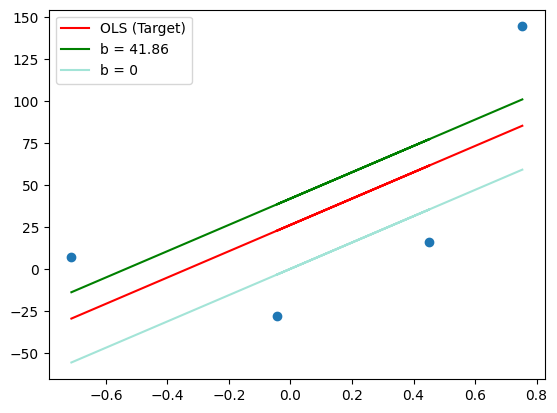

In [21]:
# Nayi y_pred calculation
y_pred_step1 = (m * X.ravel()) + b

# Plot karke check karein
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS (Target)')
plt.plot(X, y_pred_step1, color='green', label=f'b = {b:.2f}')
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')

plt.legend()
plt.show()

In [22]:
#iteration 2
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(125.5665804492553)

In [23]:
b=b-(lr*loss_slope)
b

np.float64(29.298868771492902)

In [24]:
y_pred2 = ((78.35 * X) + b).reshape(4)


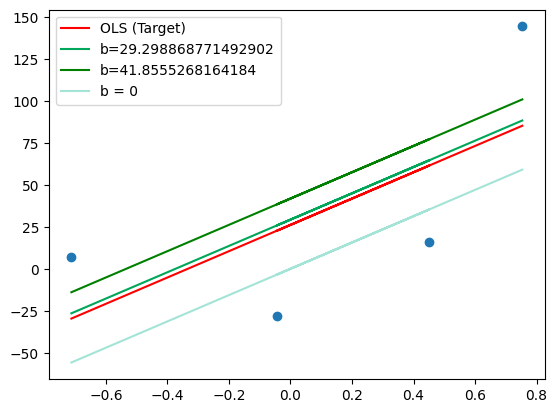

In [27]:
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS (Target)')
plt.plot(X,y_pred2,color='#00a65a',label='b=29.298868771492902')
plt.plot(X, y_pred_step1, color='green', label='b=41.8555268164184')
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')

plt.legend()
plt.show()

In [28]:
#iteration 3
loss_slope=-2*np.sum(y-m*X.ravel()-b)
loss_slope

np.float64(25.113316089851054)

In [29]:
b=b-(lr*loss_slope)
b

np.float64(26.787537162507796)

In [30]:
y_pred3 = ((78.35 * X) + b).reshape(4)


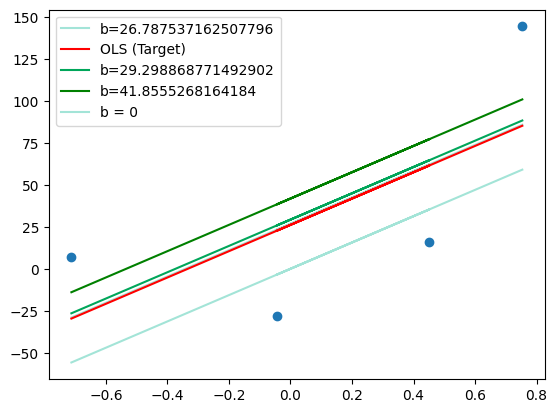

In [32]:
plt.scatter(X, y)
plt.plot(X,y_pred3,color='#A3E4D8',label='b=26.787537162507796')
plt.plot(X, reg.predict(X), color='red', label='OLS (Target)')
plt.plot(X,y_pred2,color='#00a65a',label='b=29.298868771492902')
plt.plot(X, y_pred_step1, color='green', label='b=41.8555268164184')
plt.plot(X,y_pred,color='#A3E4D7',label='b = 0')


plt.legend()
plt.show()

In [33]:
# Initial values
m = 0
b = 0

learning_rate = 0.01
epochs = 100

# Loop through iterations
for i in range(epochs):
    # Predictions calculation
    y_pred = m * X.ravel() + b

    # Derivatives / Slopes calculate karein
    loss_slope_b = -2 * np.sum(y - y_pred)
    loss_slope_m = -2 * np.sum((y - y_pred) * X.ravel())

    # Dono ko ek saath update karein
    b = b - (learning_rate * loss_slope_b)
    m = m - (learning_rate * loss_slope_m)

print("Final slope (m):", m)
print("Final intercept (b):", b)

Final slope (m): 72.106294648799
Final intercept (b): 27.15578442142949


In [34]:
# Epochs 100 se badha kar 500 ya 1000 kar ke dekhein
epochs = 500

for i in range(epochs):
    y_pred = m * X.ravel() + b
    loss_slope_b = -2 * np.sum(y - y_pred)
    loss_slope_m = -2 * np.sum((y - y_pred) * X.ravel())

    b = b - (learning_rate * loss_slope_b)
    m = m - (learning_rate * loss_slope_m)

print("Final slope (m):", m)
print("Final intercept (b):", b)

Final slope (m): 78.35060665697517
Final intercept (b): 26.159637670683193


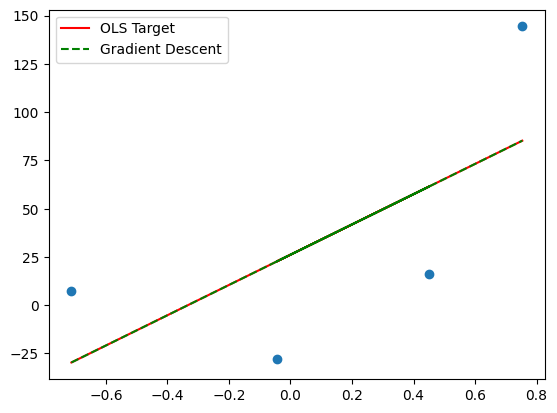

In [35]:
plt.scatter(X, y)
plt.plot(X, reg.predict(X), color='red', label='OLS Target')
plt.plot(X, m * X.ravel() + b, color='green', linestyle='--', label='Gradient Descent')
plt.legend()
plt.show()

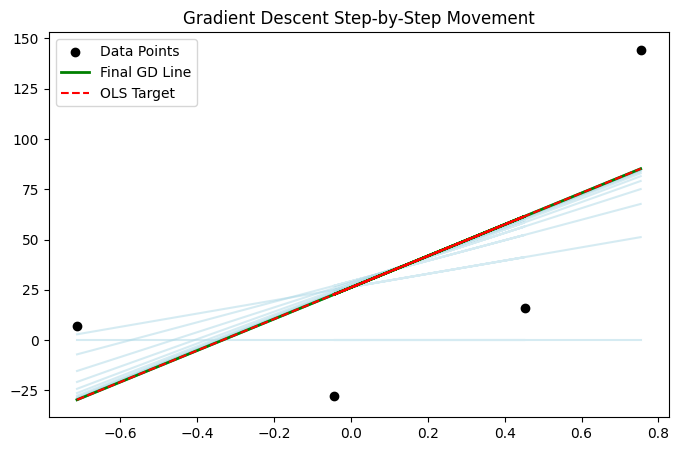

Final slope (m): 78.35028911327383
Final intercept (b): 26.159688730997516


In [36]:
#
import matplotlib.pyplot as plt

# Initial parameters
m = 0
b = 0
learning_rate = 0.01
epochs = 500

plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='black', label='Data Points')

# Epochs ka loop
for i in range(epochs):
    y_pred = m * X.ravel() + b

    # Har 20 iterations par line draw karein taaki graph saaf dikhe
    if i % 20 == 0:
        plt.plot(X, y_pred, color='lightblue', alpha=0.5)

    # Derivatives & updates
    loss_slope_b = -2 * np.sum(y - y_pred)
    loss_slope_m = -2 * np.sum((y - y_pred) * X.ravel())

    b = b - (learning_rate * loss_slope_b)
    m = m - (learning_rate * loss_slope_m)

# Final Gradient Descent line & OLS target
plt.plot(X, m * X.ravel() + b, color='green', linewidth=2, label='Final GD Line')
plt.plot(X, reg.predict(X), color='red', linestyle='--', label='OLS Target')

plt.title("Gradient Descent Step-by-Step Movement")
plt.legend()
plt.show()

print("Final slope (m):", m)
print("Final intercept (b):", b)